<a href="https://colab.research.google.com/github/srj1407/Data_Science_and_ML/blob/main/Business_Case_LoanTap_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('logistic_regression.csv')

In [ ]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [ ]:
df.head().T

,0,1,2,3,4
loan_amnt,10000.0,8000.0,15600.0,7200.0,24375.0
term,36 months,36 months,36 months,36 months,60 months
int_rate,11.44,11.99,10.49,6.49,17.27
installment,329.48,265.68,506.97,220.65,609.33
grade,B,B,B,A,C
sub_grade,B4,B5,B3,A2,C5
emp_title,Marketing,Credit analyst,Statistician,Client Advocate,Destiny Management Inc.
emp_length,10+ years,4 years,< 1 year,6 years,9 years
home_ownership,RENT,MORTGAGE,RENT,RENT,MORTGAGE
annual_inc,117000.0,65000.0,43057.0,54000.0,55000.0


In [ ]:
df.shape

(396030, 27)

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [ ]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [ ]:
df.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,22927
emp_length,18301
home_ownership,0
annual_inc,0


### Insights after basic analysis

Based on the initial data exploration, here are some key observations:

*   **Dataset Size**: The dataset contains 396,030 entries and 27 columns.
*   **Missing Values**: Several columns have missing values that will need to be addressed in the data cleaning phase:
    *   `emp_title` (22927 missing)
    *   `emp_length` (18301 missing)
    *   `title` (1756 missing)
    *   `revol_util` (276 missing)
    *   `mort_acc` (37795 missing)
    *   `pub_rec_bankruptcies` (535 missing)
*   **Data Types**:
    *   `term`: Currently an `object` type (e.g., ' 36 months', ' 60 months'), it needs to be converted to numerical (e.g., 36, 60).
    *   `issue_d` and `earliest_cr_line`: These are `object` type and should be converted to datetime objects for time-based feature engineering.
*   **Target Variable**: `loan_status` is the target variable, indicating if a loan was 'Fully Paid' or 'Charged Off'. This will need encoding.
*   **High Cardinality Categorical Features**: `emp_title` and `title` have a very large number of unique values (173,106 and 48,816 respectively), suggesting that these columns might require advanced encoding techniques (like target encoding) or grouping.
*   **Address Information**: The `address` column can be used to extract `zip_code` which might be a useful geographical feature.
*   **No Duplicate Rows**: An initial check for duplicate rows indicates that there are no exact duplicate entries in the dataset.

# Data Cleaning

## Fixing Data Types

In [ ]:
df['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

The text values should be mapped to numerical values. ' 36 months' to 36 and ' 60 months' to 60.


In [ ]:
df['term'] = df['term'].map({' 36 months': 36, ' 60 months': 60}).astype('float64')
df['term']

,term
0,36.0
1,36.0
2,36.0
3,36.0
4,60.0
...,...
396025,60.0
396026,36.0
396027,36.0
396028,60.0


In [ ]:
df['term'].dtype

dtype('float64')

In [ ]:
df['grade'].unique() # We should perform ordinal encoding here

array(['B', 'A', 'C', 'E', 'D', 'F', 'G'], dtype=object)

In [ ]:
df['sub_grade'].unique() # We should perform ordinal encoding here

array(['B4', 'B5', 'B3', 'A2', 'C5', 'C3', 'A1', 'B2', 'C1', 'A5', 'E4',
       'A4', 'A3', 'D1', 'C2', 'B1', 'D3', 'D5', 'D2', 'E1', 'E2', 'E5',
       'F4', 'E3', 'D4', 'G1', 'F5', 'G2', 'C4', 'F1', 'F3', 'G5', 'G4',
       'F2', 'G3'], dtype=object)

In [ ]:
emp_title = list(df['emp_title'].unique())
print(len(emp_title))

173106


In [ ]:
df['emp_title'].value_counts().tail(30)

,count
emp_title,
Hivelocity Hosting,1
Tufting,1
inpatient coder,1
SR. TECH ANALYST,1
Adminstratrive Coordinator & Supervisor,1
Alarm Monitor,1
Wearhouse Selector,1
Machine oper,1
3 Solutions LLC,1


In [ ]:
df['emp_title'].value_counts().head(30) # We should target encode this column with smoothing

,count
emp_title,
Teacher,4389
Manager,4250
Registered Nurse,1856
RN,1846
Supervisor,1830
Sales,1638
Project Manager,1505
Owner,1410
Driver,1339


In [ ]:
df['emp_title'] = df['emp_title'].astype(str).str.lower().str.strip()

In [ ]:
df['emp_length'].unique() # We should perform manual encoding here and replace missing values with median value

array(['10+ years', '4 years', '< 1 year', '6 years', '9 years',
       '2 years', '3 years', '8 years', '7 years', '5 years', '1 year',
       nan], dtype=object)

In [ ]:
df['emp_length'] = df['emp_length'].map({'10+ years': 10, '4 years': 4, '< 1 year': 0, '6 years': 6, '9 years': 9, '2 years': 2, '3 years': 3, '8 years': 8, '7 years': 7, '5 years': 5, '1 year': 1})

In [ ]:
df['emp_length'].unique()

array([10.,  4.,  0.,  6.,  9.,  2.,  3.,  8.,  7.,  5.,  1., nan])

In [ ]:
df['home_ownership'].unique() # We should perform one hot encoding here after combining other , none and any rows as other

array(['RENT', 'MORTGAGE', 'OWN', 'OTHER', 'NONE', 'ANY'], dtype=object)

In [ ]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,198348
RENT,159790
OWN,37746
OTHER,112
NONE,31
ANY,3


In [ ]:
df['verification_status'].unique() # We should perform one hot encoding here

array(['Not Verified', 'Source Verified', 'Verified'], dtype=object)

In [ ]:
df['verification_status'].value_counts()

,count
verification_status,
Verified,139563
Source Verified,131385
Not Verified,125082


In [ ]:
df['issue_d'].value_counts()

,count
issue_d,
Oct-2014,14846
Jul-2014,12609
Jan-2015,11705
Dec-2013,10618
Nov-2013,10496
...,...
Aug-2007,26
Sep-2008,25
Nov-2007,22


In [ ]:
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

In [ ]:
df['issue_d'] # We should find the difference with the earliest_cr_line column and drop this column

,issue_d
0,2015-01-01
1,2015-01-01
2,2015-01-01
3,2014-11-01
4,2013-04-01
...,...
396025,2015-10-01
396026,2015-02-01
396027,2013-10-01
396028,2012-08-01


In [ ]:
df['loan_status'].unique()

array(['Fully Paid', 'Charged Off'], dtype=object)

In [ ]:
df['loan_status'].value_counts() # We should one hot encode this column

,count
loan_status,
Fully Paid,318357
Charged Off,77673


In [ ]:
df['purpose'].unique()

array(['vacation', 'debt_consolidation', 'credit_card',
       'home_improvement', 'small_business', 'major_purchase', 'other',
       'medical', 'wedding', 'car', 'moving', 'house', 'educational',
       'renewable_energy'], dtype=object)

In [ ]:
df['purpose'].value_counts() # We should one hot encode this column

,count
purpose,
debt_consolidation,234507
credit_card,83019
home_improvement,24030
other,21185
major_purchase,8790
small_business,5701
car,4697
medical,4196
moving,2854


In [ ]:
df['title'].unique()

array(['Vacation', 'Debt consolidation', 'Credit card refinancing', ...,
       'Credit buster ', 'Loanforpayoff', 'Toxic Debt Payoff'],
      dtype=object)

In [ ]:
df['title'].value_counts() # We should target encode this column with smoothing

,count
title,
Debt consolidation,152472
Credit card refinancing,51487
Home improvement,15264
Other,12930
Debt Consolidation,11608
...,...
creditcardrefi,1
Debt/Home,1
Peace Of Mind Loan,1


In [ ]:
df['title'] = df['title'].astype(str).str.lower().str.strip()

In [ ]:
df['title']

,title
0,vacation
1,debt consolidation
2,credit card refinancing
3,credit card refinancing
4,credit card refinance
...,...
396025,debt consolidation
396026,debt consolidation
396027,pay off credit cards
396028,loanforpayoff


In [ ]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

In [ ]:
df['earliest_cr_line'].head()

,earliest_cr_line
0,1990-06-01
1,2004-07-01
2,2007-08-01
3,2006-09-01
4,1999-03-01


In [ ]:
df['revol_util'] #This columns requires imputing

,revol_util
0,41.8
1,53.3
2,92.2
3,21.5
4,69.8
...,...
396025,34.3
396026,95.7
396027,66.9
396028,53.8


In [ ]:
df['initial_list_status']

,initial_list_status
0,w
1,f
2,f
3,f
4,f
...,...
396025,w
396026,f
396027,f
396028,f


In [ ]:
df['initial_list_status'].unique() # We should one hot encode this column

array(['w', 'f'], dtype=object)

In [ ]:
df['application_type']

,application_type
0,INDIVIDUAL
1,INDIVIDUAL
2,INDIVIDUAL
3,INDIVIDUAL
4,INDIVIDUAL
...,...
396025,INDIVIDUAL
396026,INDIVIDUAL
396027,INDIVIDUAL
396028,INDIVIDUAL


In [ ]:
df['application_type'].unique()  # We should do one hot encoding for this feature

array(['INDIVIDUAL', 'JOINT', 'DIRECT_PAY'], dtype=object)

In [ ]:
df['mort_acc'].isna().sum()

np.int64(37795)

In [ ]:
df['mort_acc'].unique()

array([ 0.,  3.,  1.,  4.,  2.,  6.,  5., nan, 10.,  7., 12., 11.,  8.,
        9., 13., 14., 22., 34., 15., 25., 19., 16., 17., 32., 18., 24.,
       21., 20., 31., 28., 30., 23., 26., 27.])

In [ ]:
df['mort_acc'] # Imputing should be done here after EDA

,mort_acc
0,0.0
1,3.0
2,0.0
3,0.0
4,1.0
...,...
396025,0.0
396026,1.0
396027,0.0
396028,5.0


In [ ]:
df['pub_rec_bankruptcies'].isnull().sum()

np.int64(535)

In [ ]:
df['pub_rec_bankruptcies'].unique()  # Imputing should be done here after EDA

array([ 0.,  1.,  2.,  3., nan,  4.,  5.,  6.,  7.,  8.])

In [ ]:
df['address'].isnull().sum()

np.int64(0)

Zip code should be extracted from this columns and new feature should be created.
This column should be dropped.

In [ ]:
df['zip_code'] = df['address'].apply(lambda x: x[-5:])

In [ ]:
df['zip_code'].value_counts()

,count
zip_code,
70466,56985
30723,56546
22690,56527
48052,55917
00813,45824
29597,45471
05113,45402
11650,11226
93700,11151


## Duplicate check

In [ ]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address,zip_code
0,10000.0,36.0,11.44,329.48,B,B4,marketing,10.0,RENT,117000.0,...,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690",22690
1,8000.0,36.0,11.99,265.68,B,B5,credit analyst,4.0,MORTGAGE,65000.0,...,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113",05113
2,15600.0,36.0,10.49,506.97,B,B3,statistician,0.0,RENT,43057.0,...,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113",05113
3,7200.0,36.0,6.49,220.65,A,A2,client advocate,6.0,RENT,54000.0,...,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813",00813
4,24375.0,60.0,17.27,609.33,C,C5,destiny management inc.,9.0,MORTGAGE,55000.0,...,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650",11650


In [ ]:
df.duplicated().sum()

np.int64(0)

It can be seen that there are no duplicate rows in this dataset.

## Domain Driven Feature Engineering

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address', 'zip_code'],
      dtype='object')

In [ ]:
df['earliest_cr_line'].isnull().sum()

np.int64(0)

Here we will create a new feature which contains the number of months that have passed since borrower's earliset credit line was opened to the issue date of the loan. This will be the difference of `issue_d` and `earliest_cr_line` features. We will drop these two columns after that.

In [ ]:
df['credit_hist_months'] = (df['issue_d'].dt.to_period('M') - df['earliest_cr_line'].dt.to_period('M')).apply(lambda x: x.n if pd.notna(x) else np.nan).astype('float64')
df['credit_hist_months']

,credit_hist_months
0,295.0
1,126.0
2,89.0
3,98.0
4,169.0
...,...
396025,131.0
396026,108.0
396027,199.0
396028,261.0


In [ ]:
df['credit_hist_months'].isnull().sum()

np.int64(0)

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address', 'zip_code',
       'credit_hist_months'],
      dtype='object')

In [ ]:
df['installment'].head()

,installment
0,329.48
1,265.68
2,506.97
3,220.65
4,609.33


In [ ]:
df['annual_inc'].head()

,annual_inc
0,117000.0
1,65000.0
2,43057.0
3,54000.0
4,55000.0


We will create a new feature `installment_to_income` which is the ratio of monthly installment which the borrower is paying to the monthly income. After that we will drop these ttwo columns - `installment` and `annual_inc`.

In [ ]:
df['installment_to_income'] = df['installment'] / ((df['annual_inc']+ 0.001) / 12)

We will create a new feature `closed_to_tot_acc` which is the ratio of `closed_acc` and `total_acc`.  The closed acc will be calculated by taking difference bwtween `total_acc` and `open_acc`. After that we will drop these two columns.

In [ ]:
df['closed_to_tot_acc'] = (df['total_acc'] - df['open_acc']) / df['total_acc']

# Exploratory Data Analysis(EDA)

## Target variable analysis

In [ ]:
df['loan_status'].value_counts(normalize = True)

,proportion
loan_status,
Fully Paid,0.803871
Charged Off,0.196129


Here we can see that our data is highly imbalanced with `80-20` ratio. Also the target data is in form of text value. First we will encode this column. Then we will apply logistic regression using scikit-learn logistic regression with `class_weight = balanced` parameter.

## Univariate: numerical features

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address', 'zip_code',
       'credit_hist_months', 'installment_to_income', 'closed_to_tot_acc'],
      dtype='object')

In [ ]:
num_cols = [x for x in df.columns if df[x].dtype == 'float64']
num_cols

['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'emp_length',
 'annual_inc',
 'dti',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'mort_acc',
 'pub_rec_bankruptcies',
 'credit_hist_months',
 'installment_to_income',
 'closed_to_tot_acc']

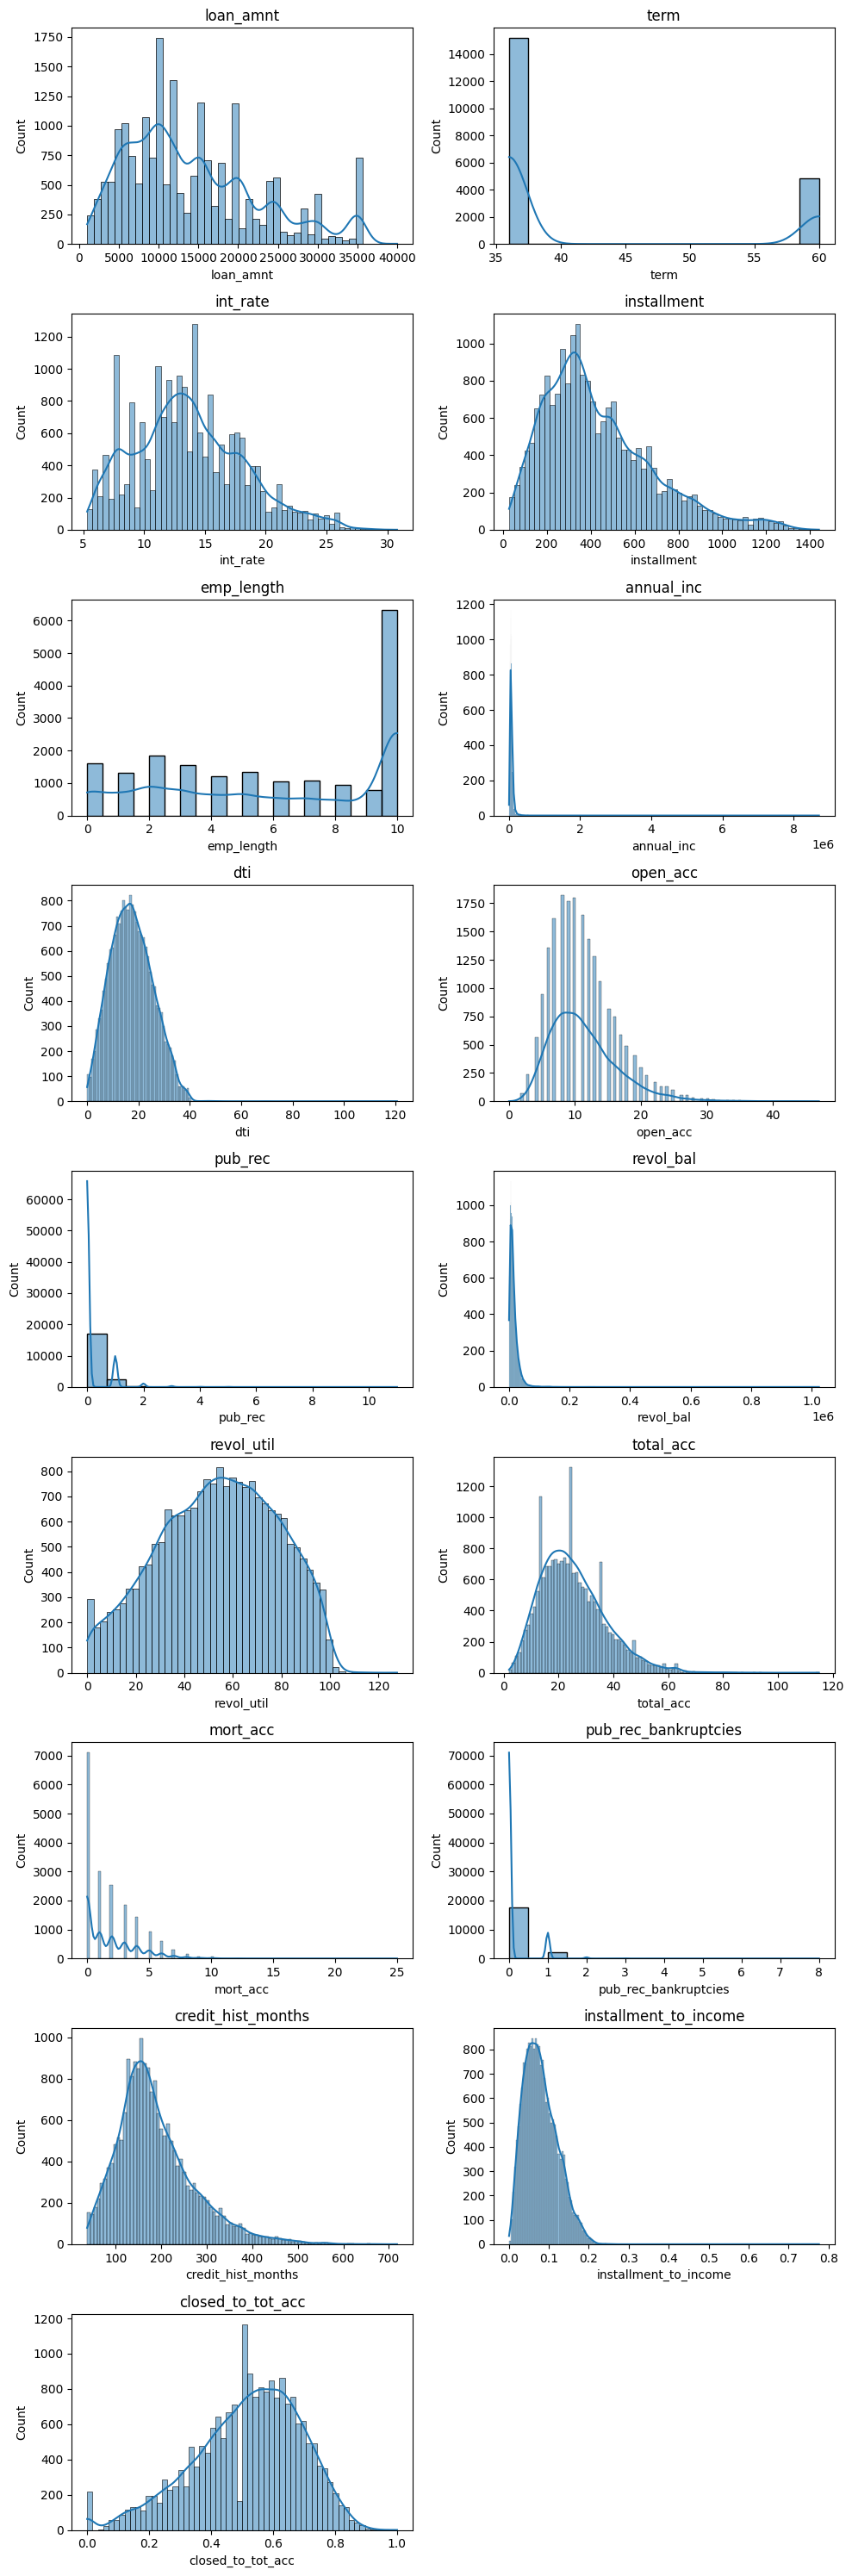

In [ ]:
plt.figure(figsize = (10, 30))
rows = (len(num_cols) + 1) // 2
cols = 2
for i in range(1, len(num_cols) + 1):
  plt.subplot(rows, cols, i)
  sns.histplot(df[num_cols[i-1]].sample(20000, random_state=42), kde = True)
  plt.title(num_cols[i-1])
plt.tight_layout()
plt.show()

In [ ]:
df.describe()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,issue_d,dti,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,credit_hist_months,installment_to_income,closed_to_tot_acc
count,396030.000000,396030.000000,396030.000000,396030.000000,377729.000000,3.960300e+05,396030,396030.000000,396030,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000,396030.000000,3.960300e+05,396030.000000
mean,14113.888089,41.698053,13.639400,431.849698,5.938578,7.420318e+04,2014-02-02 15:57:58.045602560,17.379514,1998-05-03 09:34:15.062495488,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648,189.053832,3.834717e+00,0.516284
min,500.000000,36.000000,5.320000,16.080000,0.000000,0.000000e+00,2007-06-01 00:00:00,0.000000,1944-01-01 00:00:00,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000,36.000000,1.231699e-04,0.000000
25%,8000.000000,36.000000,10.490000,250.330000,3.000000,4.500000e+04,2013-05-01 00:00:00,11.280000,1994-10-01 00:00:00,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000,131.000000,4.759200e-02,0.409091
50%,12000.000000,36.000000,13.330000,375.430000,6.000000,6.400000e+04,2014-04-01 00:00:00,16.910000,1999-09-01 00:00:00,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000,172.000000,7.363552e-02,0.538462
75%,20000.000000,36.000000,16.490000,567.300000,10.000000,9.000000e+04,2015-03-01 00:00:00,22.980000,2003-04-01 00:00:00,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000,232.000000,1.060773e-01,0.642857
max,40000.000000,60.000000,30.990000,1533.810000,10.000000,8.706582e+06,2016-12-01 00:00:00,9999.000000,2013-10-01 00:00:00,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000,842.000000,1.487280e+06,1.000000
std,8357.441341,10.212038,4.472157,250.727790,3.645623,6.163762e+04,NaN,18.019092,NaN,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174,86.412799,2.363353e+03,0.173912


It can be seen from the above plots that loan_amt, installment, annual_inc, revol_bal, credit_hist_months, are slightly right skewed. closed_to_tot_acc is slightly left skewed.

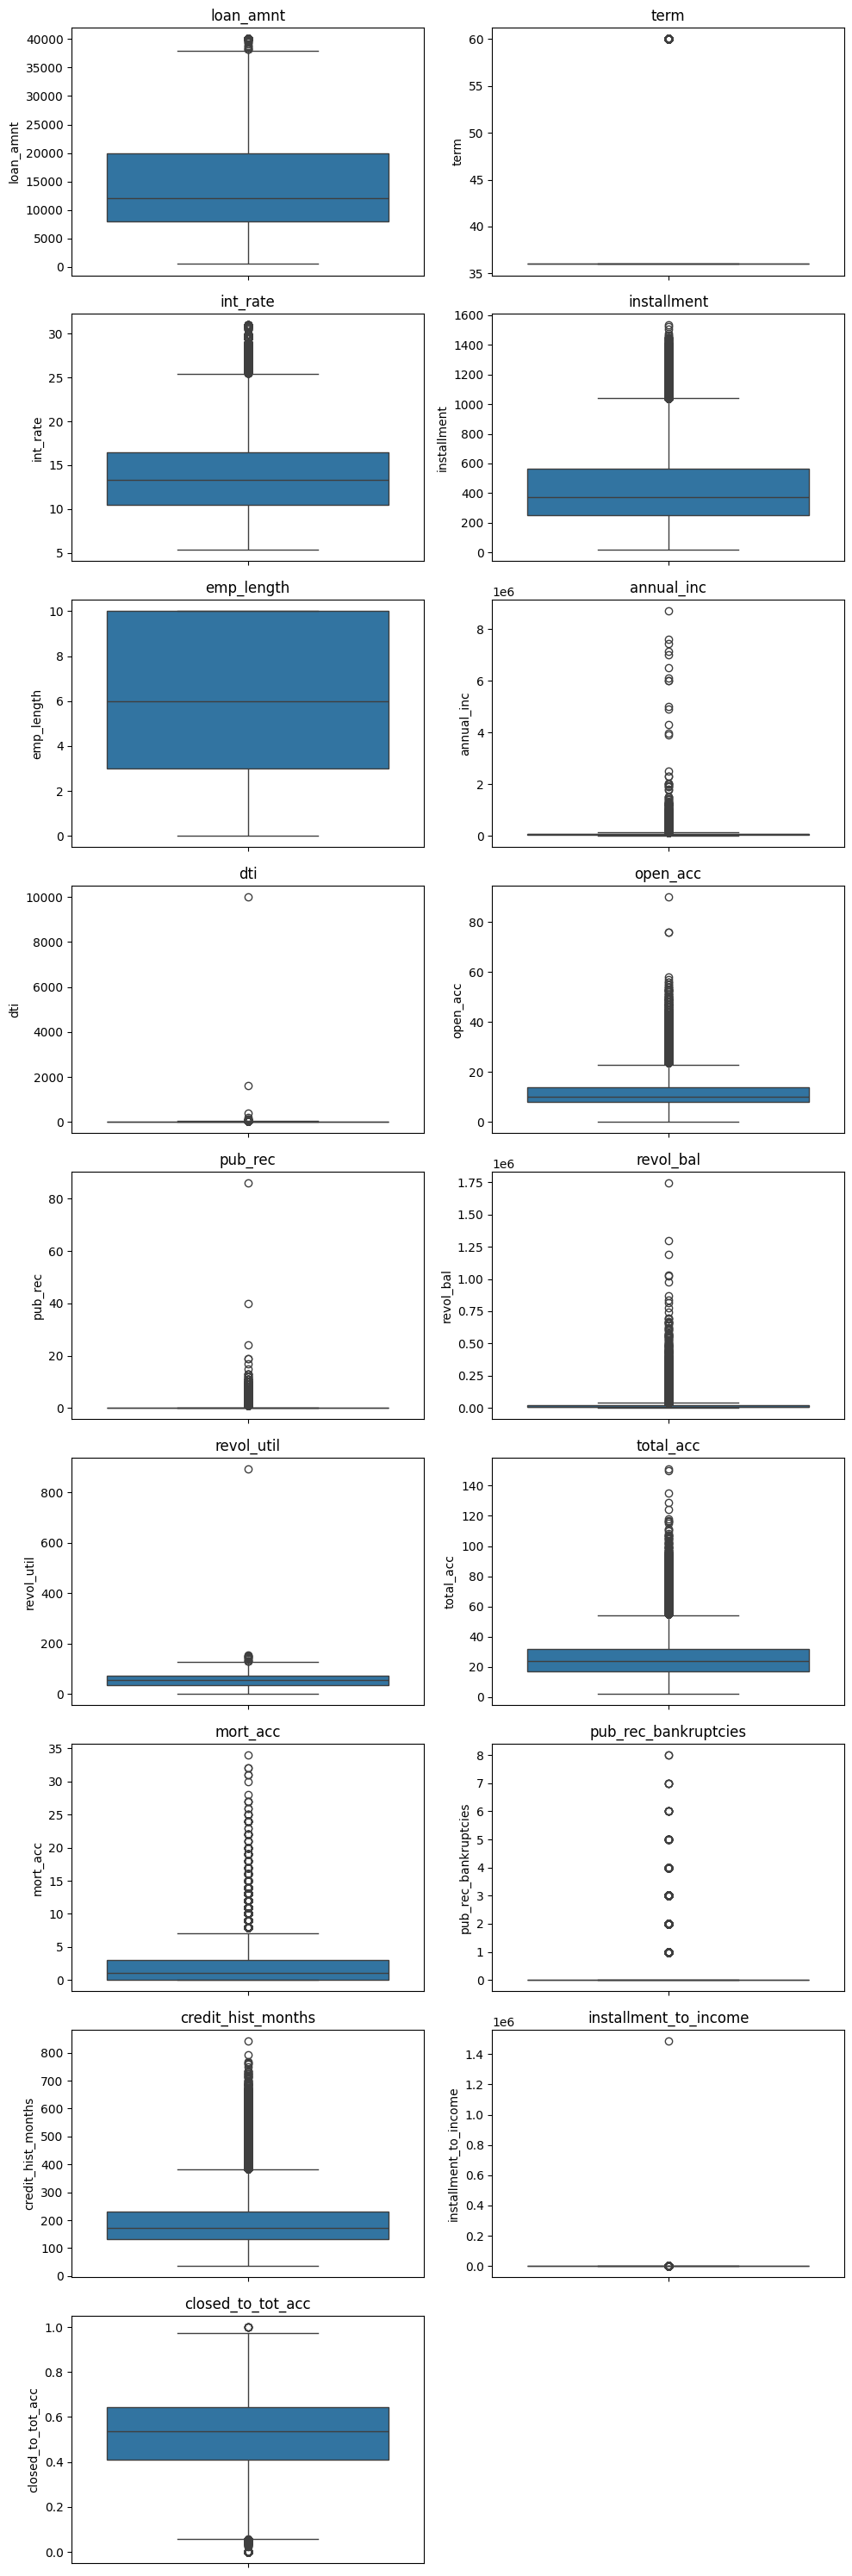

In [ ]:
plt.figure(figsize = (10, 30))
rows = (len(num_cols) + 1) // 2
cols = 2 # Setting two columns
for i in range(1, len(num_cols) + 1):
  plt.subplot(rows, cols, i)
  sns.boxplot(df[num_cols[i-1]])
  plt.title(num_cols[i-1])
plt.tight_layout()
plt.show()

It can be seen from the above box plts that (int_rate, installment, annual_inc, dti, open_acc, pub_rec, revol_bal, revol_util, tot_acc, mort_acc, pub_rec_bankruptcies, credit_hist_months, installment_to_income), these all are having outliers. These outliers need to be handled later.

In [ ]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    total_outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percent = total_outliers / len(df)
    outlier_summary[col] = [total_outliers, outlier_percent]

print(pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['Outlier_Count', 'Outlier percent']))


                       Outlier_Count  Outlier percent
loan_amnt                        191         0.000482
term                           94025         0.237419
int_rate                        3777         0.009537
installment                    11250         0.028407
emp_length                         0         0.000000
annual_inc                     16700         0.042169
dti                              275         0.000694
open_acc                       10307         0.026026
pub_rec                        57758         0.145842
revol_bal                      21259         0.053680
revol_util                        12         0.000030
total_acc                       8499         0.021460
mort_acc                        6843         0.017279
pub_rec_bankruptcies           45115         0.113918
credit_hist_months             12936         0.032664
installment_to_income           2167         0.005472
closed_to_tot_acc               4697         0.011860


### Numerical Feature Insights

Based on the univariate analysis of numerical features:

*   **Skewness**: Histograms revealed that `loan_amnt`, `installment`, `annual_inc`, `revol_bal`, and `credit_hist_months` are slightly right-skewed. `closed_to_tot_acc` shows a slight left skew.

*   **Outliers**: Box plots and the outlier summary table indicate the presence of outliers in many numerical features. Notably, `term`, `pub_rec`, and `pub_rec_bankruptcies` have a significant percentage of outliers. These outliers will need appropriate handling, such as capping or Winsorization, in later steps.

## Univariate: categorical features

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 31 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   loan_amnt              396030 non-null  float64       
 1   term                   396030 non-null  float64       
 2   int_rate               396030 non-null  float64       
 3   installment            396030 non-null  float64       
 4   grade                  396030 non-null  object        
 5   sub_grade              396030 non-null  object        
 6   emp_title              396030 non-null  object        
 7   emp_length             377729 non-null  float64       
 8   home_ownership         396030 non-null  object        
 9   annual_inc             396030 non-null  float64       
 10  verification_status    396030 non-null  object        
 11  issue_d                396030 non-null  datetime64[ns]
 12  loan_status            396030 non-null  obje

In [ ]:
cat_cols = ['grade', 'sub_grade', 'emp_title', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'title', 'initial_list_status', 'application_type']

In [ ]:
# Plot bar chart

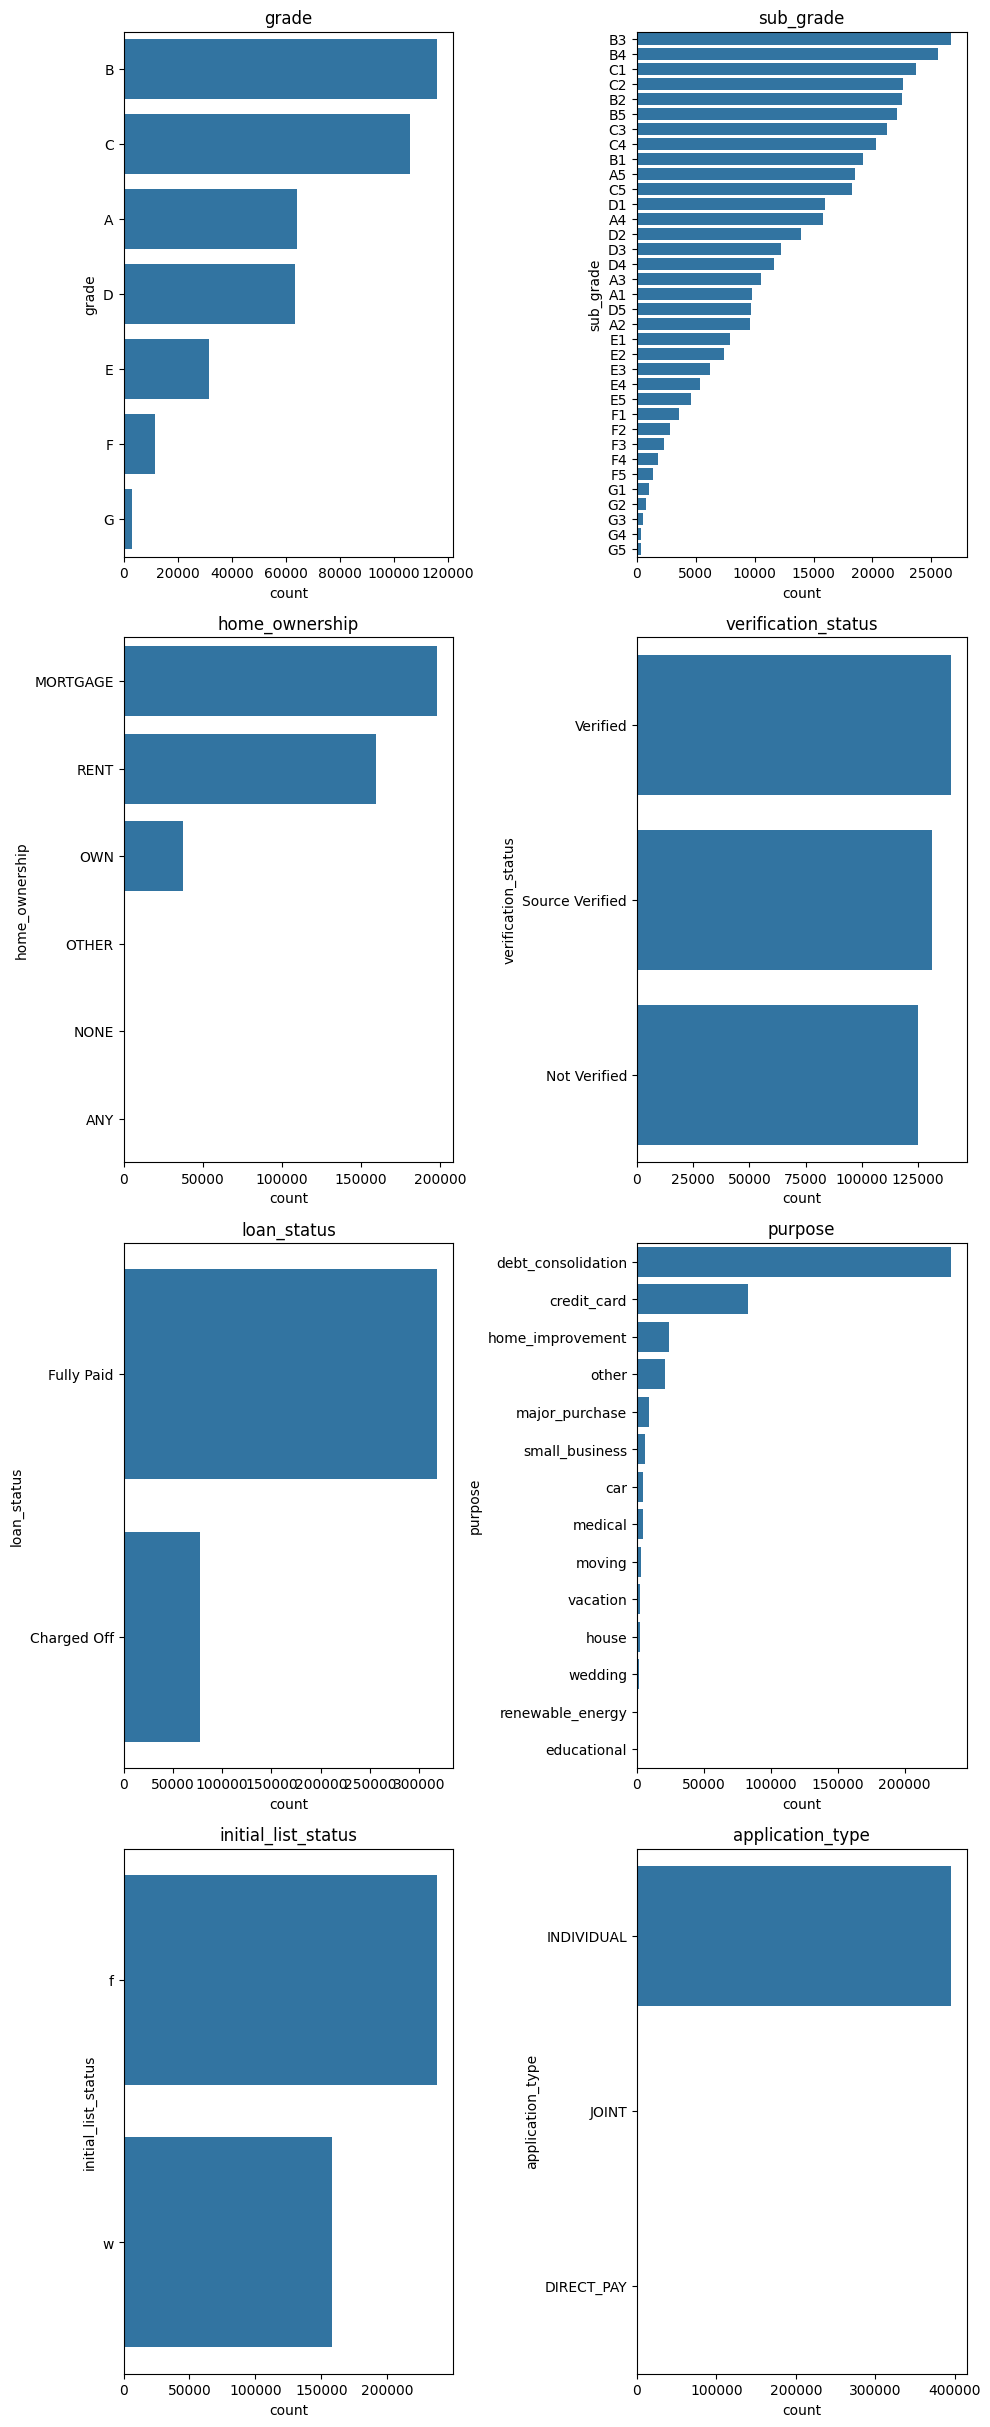

In [ ]:
plt.figure(figsize = (10, 30))
rows = (len(cat_cols) + 1) // 2
cols = 2

cat_cols_to_plot = [col for col in cat_cols if col not in ['emp_title', 'title']]

for i in range(len(cat_cols_to_plot)):
  plt.subplot(rows, cols, i+1)
  sns.countplot(y=df[cat_cols_to_plot[i]], order = df[cat_cols_to_plot[i]].value_counts().index)
  plt.title(cat_cols_to_plot[i])
plt.tight_layout()
plt.show()

loan_status -> Use balancing parameter while applying logistic

purpose -> bundle smaller groups into one

home_ownership -> bundle smaller groups

application_type -> drop(since only one category has majority data)

grade, sub grade, verification_status, initial_status -> Follow normal process of scaling and encoding

### Categorical Feature Insights

Based on the univariate analysis of categorical features:

*   **Loan Status Imbalance**: The target variable `loan_status` is highly imbalanced, with approximately 80% 'Fully Paid' and 20% 'Charged Off'. This will need to be addressed during model training, for example, by using `class_weight='balanced'` in logistic regression.

*   **Purpose and Home Ownership Grouping**: `purpose` and `home_ownership` have several categories with very few observations. These smaller groups will be combined into an 'Other' category before one-hot encoding to avoid creating too many sparse features.

*   **High Cardinality Features**: `emp_title` and `title` exhibited very high cardinality, making standard one-hot encoding impractical. These were handled using target encoding with smoothing.

*   **Encoding Strategies**:
    *   `grade` and `sub_grade`: These features are ordinal and will be handled using ordinal encoding.
    *   `verification_status` and `initial_list_status`: These are nominal features suitable for one-hot encoding.
    *   `application_type`: While initially considered for one-hot encoding, it might be dropped due to one category having a significant majority of data, making it less informative after encoding.

*   **Actionable Insights**: Specific categories within features like `grade`, `home_ownership`, and `purpose` showed varying distributions of `loan_status`, indicating their predictive power.

## Bivariate: numerical vs target

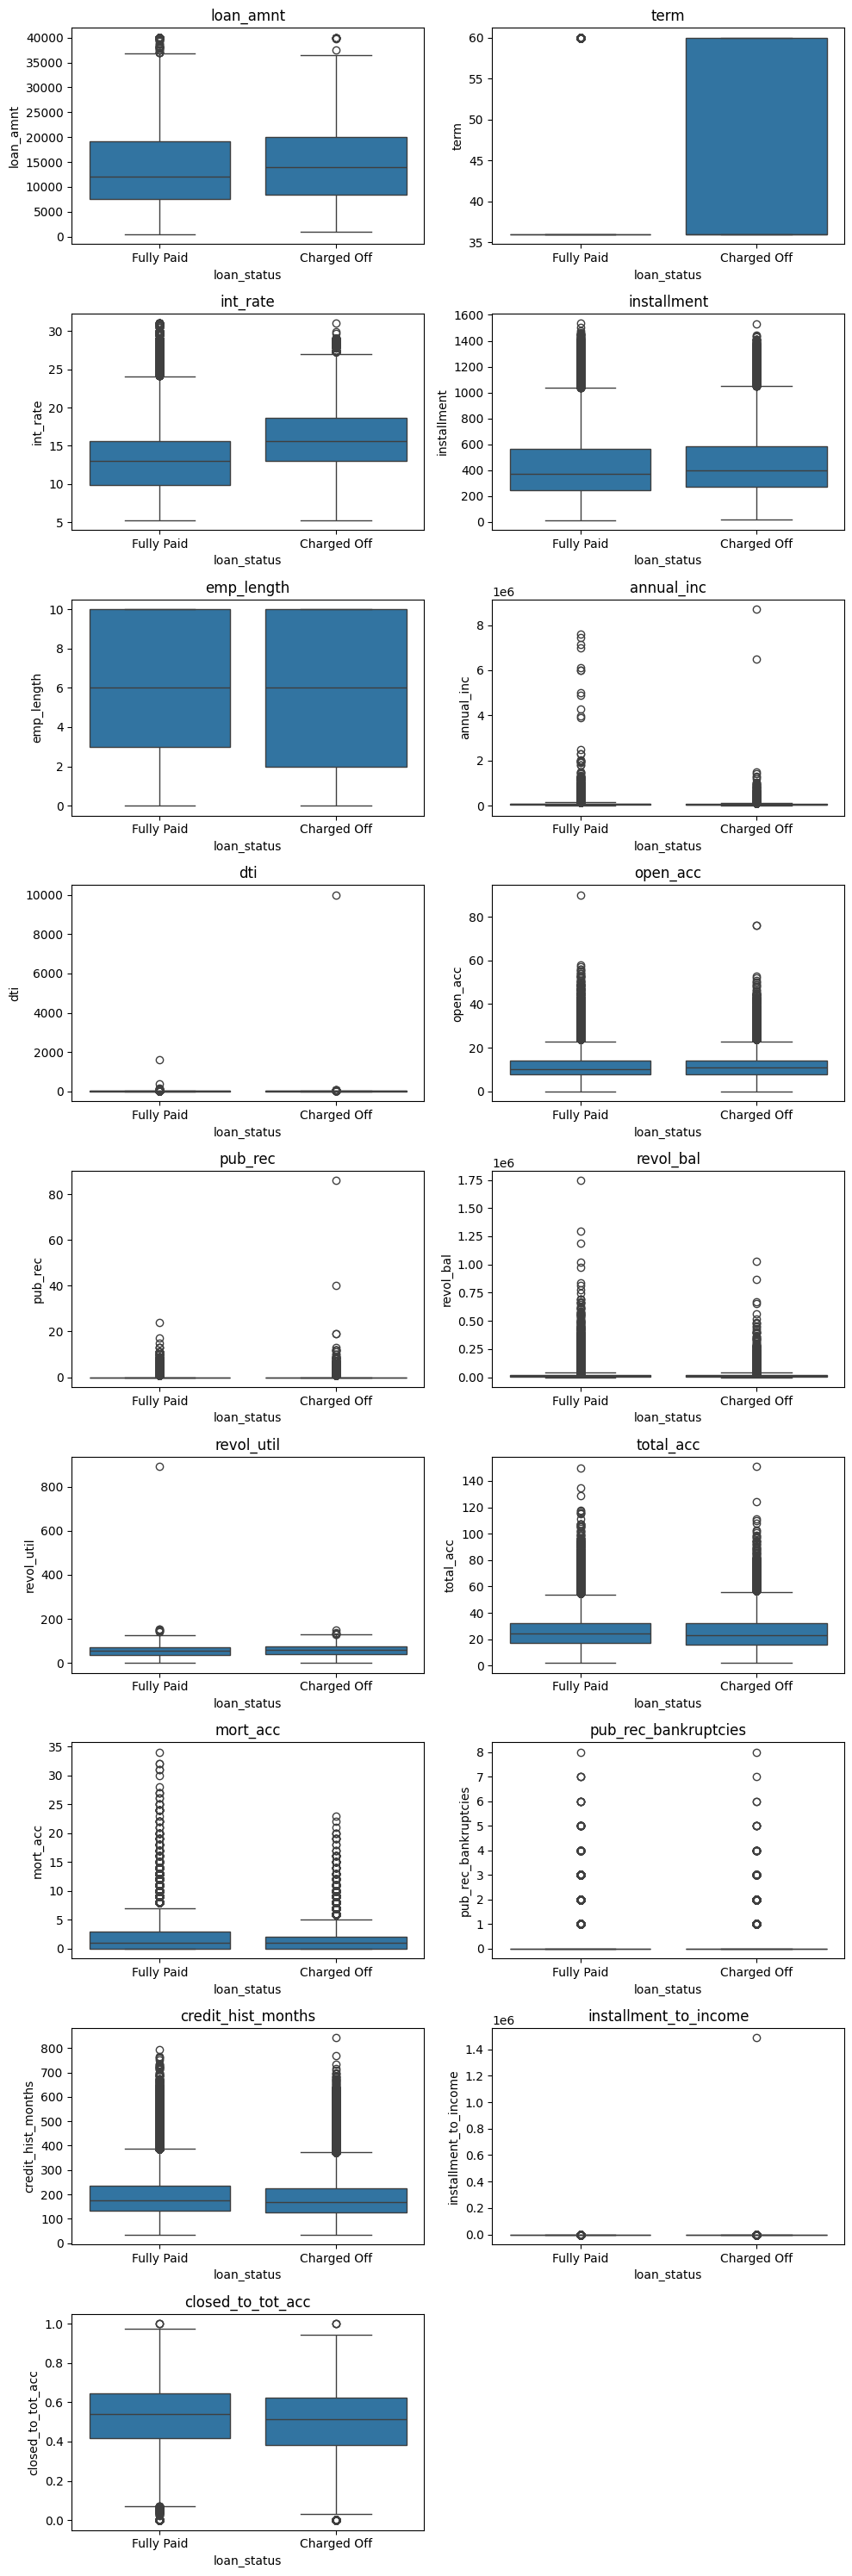

In [ ]:
plt.figure(figsize = (10, 30))
rows = (len(num_cols) + 1) // 2
cols = 2
for i in range(len(num_cols)):
  plt.subplot(rows, cols, i + 1)
  sns.boxplot(x='loan_status', y=num_cols[i], data=df)
  plt.title(num_cols[i])
plt.tight_layout()
plt.show()

loan_amnt & installment:

Perform Domain-Driven Feature Engineering (Step 2) by creating a ratio:
(\text{installment\_to\_income\_ratio}=\frac{\text{installment}}{\text{annual\_inc}/12}\)

open_acc & total_acc:
\(\text{closed\_acc\_ratio}=\frac{\text{total\_acc}-\text{open\_acc}}{\text{total\_acc}}\)

annual_inc & revol_bal:
Capping

dti:
Remove one outlier with 1000 as entry

pub_rec_bankruptcies & pub_rec: Leave these as it is

In [ ]:
mean_summary_table = df.groupby('loan_status')[num_cols].mean()
print(mean_summary_table.T)

loan_status             Charged Off    Fully Paid
loan_amnt              15126.300967  13866.878771
term                      45.279827     40.824169
int_rate                  15.882587     13.092105
installment              452.703110    426.761866
emp_length                 5.835961      5.963008
annual_inc             67535.537710  75829.951566
dti                       19.656346     16.824010
open_acc                  11.602513     11.240067
pub_rec                    0.199606      0.172966
revol_bal              15390.454701  15955.327918
revol_util                57.869824     52.796918
total_acc                 24.984152     25.519800
mort_acc                   1.501213      1.892836
pub_rec_bankruptcies       0.128412      0.119997
credit_hist_months       184.337350    190.204563
installment_to_income     19.237936      0.076627
closed_to_tot_acc          0.494828      0.521518


### Numerical vs. Target Insights

Based on the bivariate analysis (box plots and mean summary table) of numerical features against `loan_status`:

*   **Loan Amount (`loan_amnt`)**: Charged off loans tend to have slightly higher loan amounts on average compared to fully paid loans. The box plots show a similar median, but the distribution for charged-off loans extends to higher values.

*   **Term (`term`)**: Loans with a 60-month term have a higher proportion of 'Charged Off' status compared to 36-month terms. This indicates that longer loan durations are associated with increased risk.

*   **Interest Rate (`int_rate`)**: There's a clear separation, with 'Charged Off' loans having significantly higher average interest rates. This is a strong indicator of risk.

*   **Installment (`installment`)**: Similar to `loan_amnt`, 'Charged Off' loans have slightly higher average monthly installments. This aligns with the correlation between `loan_amnt` and `installment`.

*   **DTI (`dti`)**: 'Charged Off' loans exhibit a higher average Debt-to-Income ratio, suggesting that borrowers with higher debt burdens relative to their income are more likely to default.

*   **Revolving Utilization (`revol_util`)**: 'Charged Off' loans tend to have a higher average `revol_util`, indicating that borrowers utilizing a larger percentage of their available credit are at higher risk.

*   **Mortgage Accounts (`mort_acc`)**: 'Fully Paid' loans generally have a higher average number of mortgage accounts. This could imply greater financial stability or a longer credit history for these borrowers.

*   **Installment to Income Ratio (`installment_to_income`)**: This engineered feature is a strong predictor, with 'Charged Off' loans having a significantly higher average ratio, indicating that a larger portion of their income goes towards loan installments.

*   **Credit History Months (`credit_hist_months`)**: 'Fully Paid' loans show a slightly longer average credit history, suggesting that borrowers with established credit are more reliable.

*   **Other Features**: `emp_length`, `open_acc`, `pub_rec`, `revol_bal`, `total_acc`, `pub_rec_bankruptcies`, and `closed_to_tot_acc` show some differences, but generally less pronounced compared to the aforementioned features, in their relationship with loan status.

## Bivariate: categorical vs target

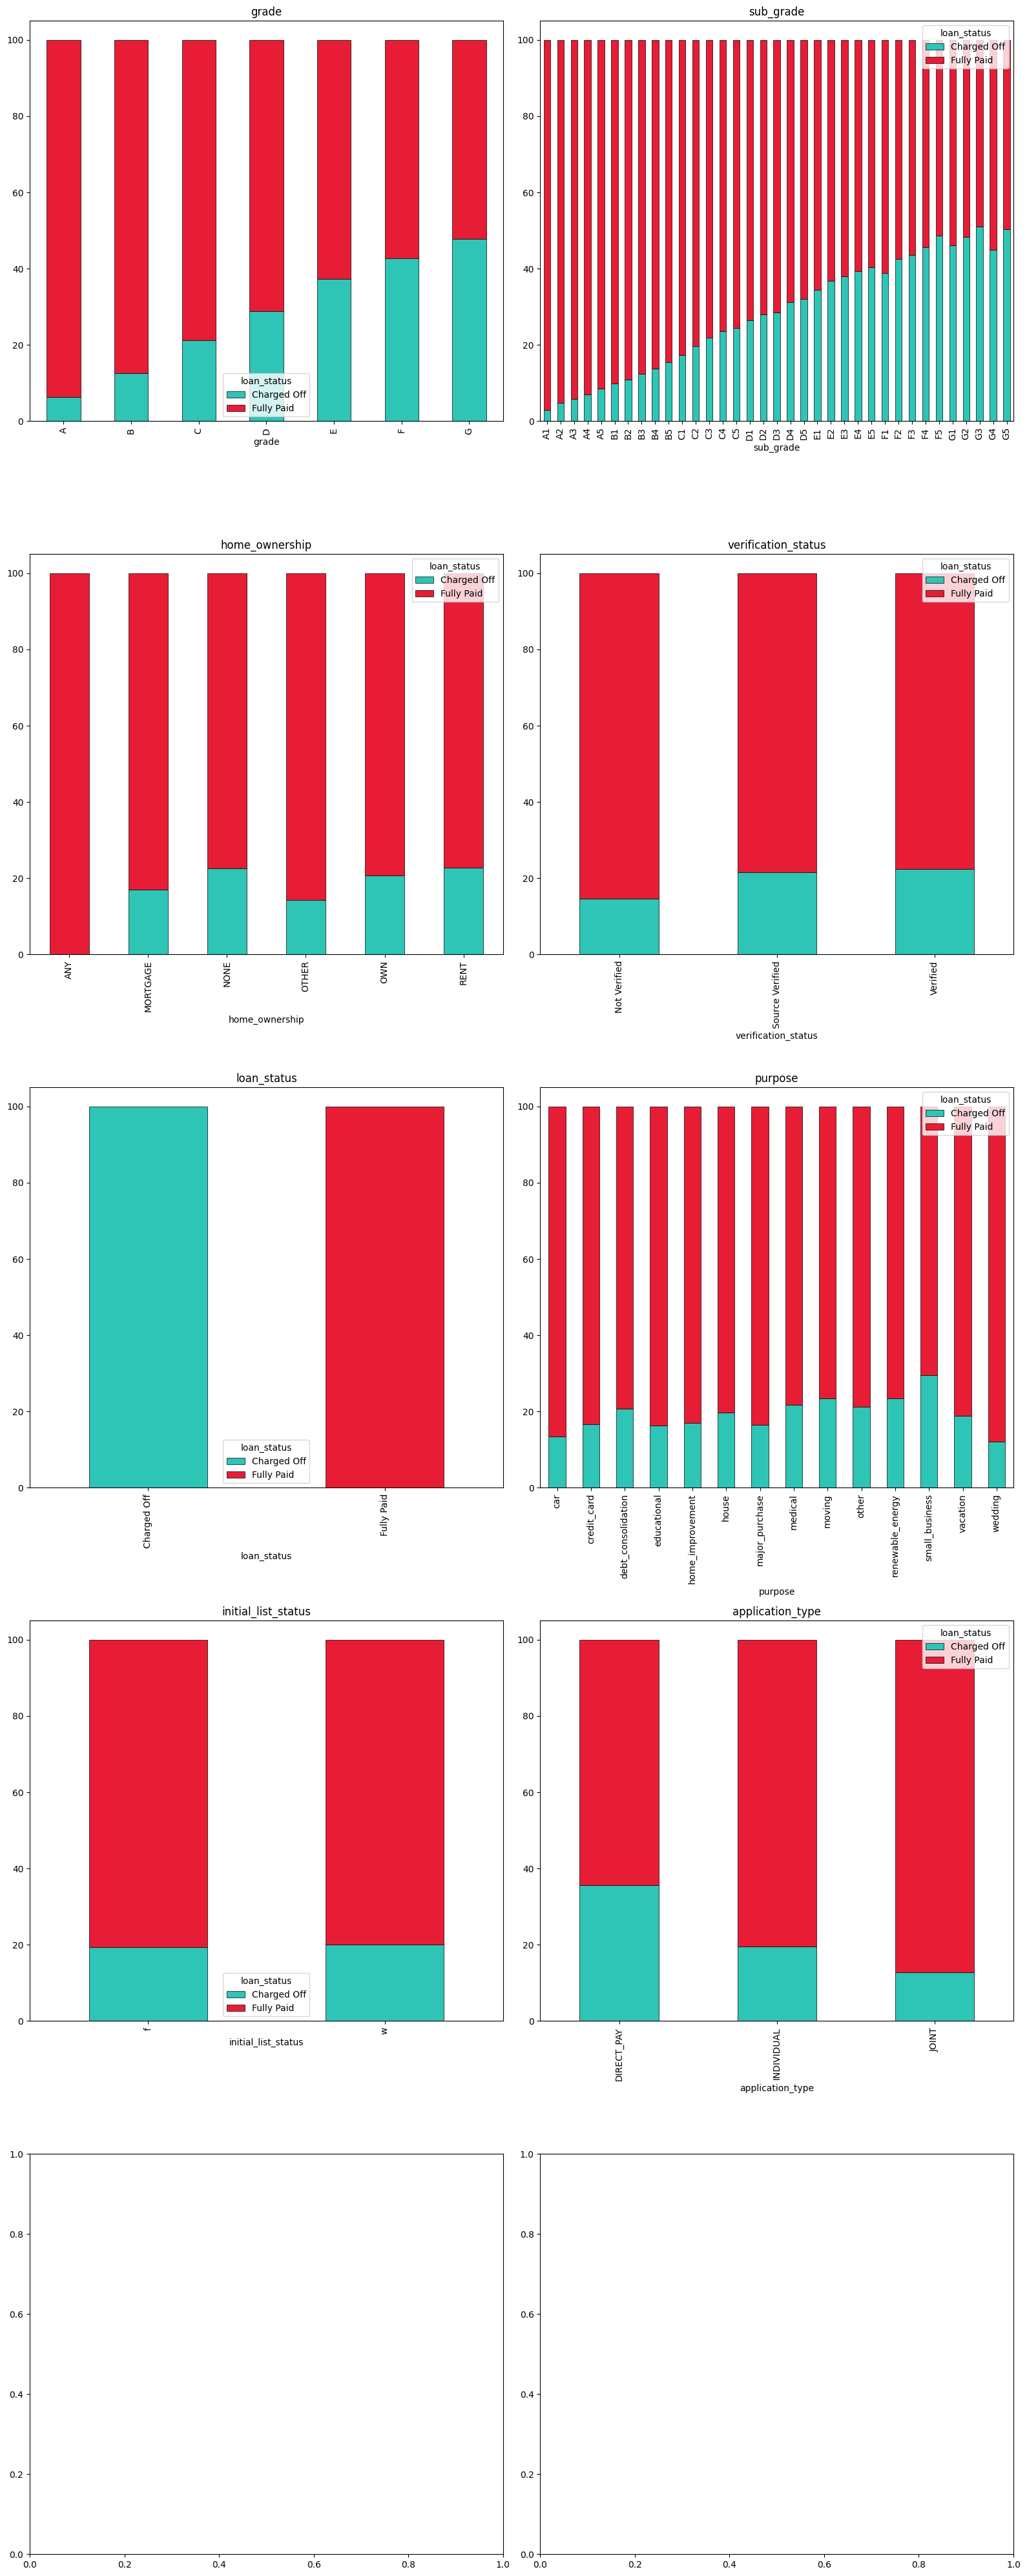

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 40))
axes = axes.flatten()

cat_cols_to_plot = [col for col in cat_cols if col not in ['emp_title', 'title']]

for index, col in enumerate(cat_cols_to_plot):
    cross_tab = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100

    cross_tab.plot(
        kind='bar',
        stacked=True,
        ax=axes[index],
        color=['#2ec4b6', '#e71d36'],
        edgecolor='black',
        linewidth=0.5
    )

    # Customise titles and labels for the current plot
    axes[index].set_title(col)

# 4. Handle any leftover empty subplots if your list size doesn't match the grid size
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

# 5. Clean up layout spacing and display
plt.tight_layout()
plt.show()


### Categorical vs. Target Insights

Based on the bivariate analysis (stacked bar plots) of categorical features against `loan_status`:

*   **Grade and Sub-Grade**: There's a clear trend: as the `grade` (and `sub_grade`) deteriorates (e.g., from A to G), the proportion of 'Charged Off' loans significantly increases. This strongly indicates that the internal grading system is a powerful predictor of default risk.

*   **Term**: As observed in the numerical insights, `term` has a direct impact. Loans with a '60 months' term consistently show a higher percentage of 'Charged Off' loans compared to '36 months' terms across various categories.

*   **Home Ownership**: Borrowers with 'RENT' and 'OTHER' `home_ownership` statuses tend to have a higher proportion of 'Charged Off' loans compared to 'MORTGAGE' and 'OWN' statuses. This suggests homeowners are generally more financially stable.

*   **Purpose**: Certain `purpose` categories show higher default rates. For instance, 'small_business' and 'debt_consolidation' might exhibit elevated risk compared to 'car' or 'vacation' loans. This highlights the importance of analyzing the intent behind the loan.

*   **Verification Status**: 'Verified' and 'Source Verified' loans, surprisingly, sometimes show a slightly higher 'Charged Off' rate than 'Not Verified' loans. This could be due to more rigorous checks being applied to riskier applicants, or it might imply that verification alone does not guarantee repayment capacity.

*   **Initial List Status**: The `initial_list_status` ('w' vs. 'f') also shows differences in default rates, indicating that the method of listing the loan can have a subtle impact.

*   **Application Type**: 'INDIVIDUAL' applications are the most common, but 'DIRECT_PAY' and 'JOINT' applications have different default rate profiles. 'JOINT' applications appear to have a lower 'Charged Off' rate, possibly due to combined incomes or shared responsibility.

*   **Encoding Implications**: The analysis reaffirms the need for appropriate encoding strategies for these features (ordinal for `grade`, one-hot for `home_ownership`, `verification_status`, `initial_list_status`, and `purpose` after grouping rare categories).

## Multivariate

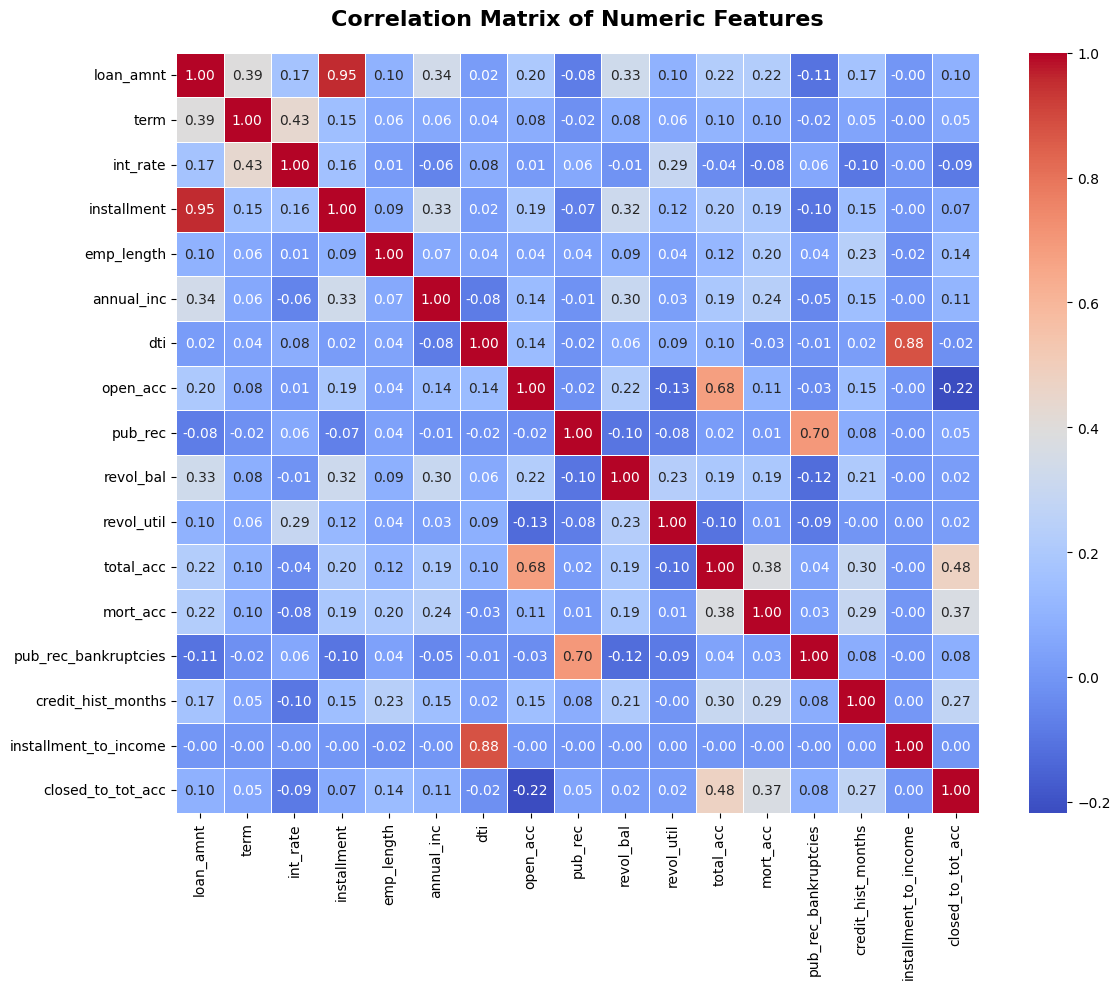

In [ ]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))

# 4. Plot the heatmap using Seaborn
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
)

# 5. Add a title and adjust layout
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


### Multivariate Insights

Based on the correlation matrix and Variance Inflation Factor (VIF) analysis:

*   **High Correlation (Original Features)**:
    *   `loan_amnt` and `installment` showed a very high positive correlation (0.95), indicating significant redundancy. This was addressed by creating a new feature (`installment_to_income`) and dropping the original `loan_amnt` and `installment` columns.
    *   `open_acc` and `total_acc` also exhibited a strong positive correlation (0.68). This was handled by engineering `closed_to_tot_acc` and subsequently dropping the original columns.
    *   `grade` and `sub_grade` were highly correlated, as expected, since `sub_grade` is a subdivision of `grade`.

*   **Multicollinearity (Post-Feature Engineering)**:
    *   After dropping highly correlated original features and performing feature engineering, the Variance Inflation Factor (VIF) analysis on the transformed features showed that most features have VIF values well below 5, suggesting that multicollinearity is not a significant issue in the final feature set for the model.
    *   `zip_code` had the highest VIF (5.55), which is acceptable, but it's important to monitor this in future iterations if more geographically related features are introduced.
    *   `purpose_debt_consolidation` also showed a VIF around 3.5, which is moderate but still within acceptable limits, indicating it shares some variance with other features but not to a problematic degree.

*   **Feature Relationships**: The heatmap provided visual confirmation of feature interdependencies, guiding decisions on which features to retain, transform, or drop to improve model stability and interpretability.

## Skewness Treatment

In [ ]:
df['log_revol_bal'] = np.log1p(df['revol_bal'])
df['log_closed_to_tot_acc'] = np.log1p(df['closed_to_tot_acc'])
df['log_credit_hist_months'] = np.log1p(df['credit_hist_months'])

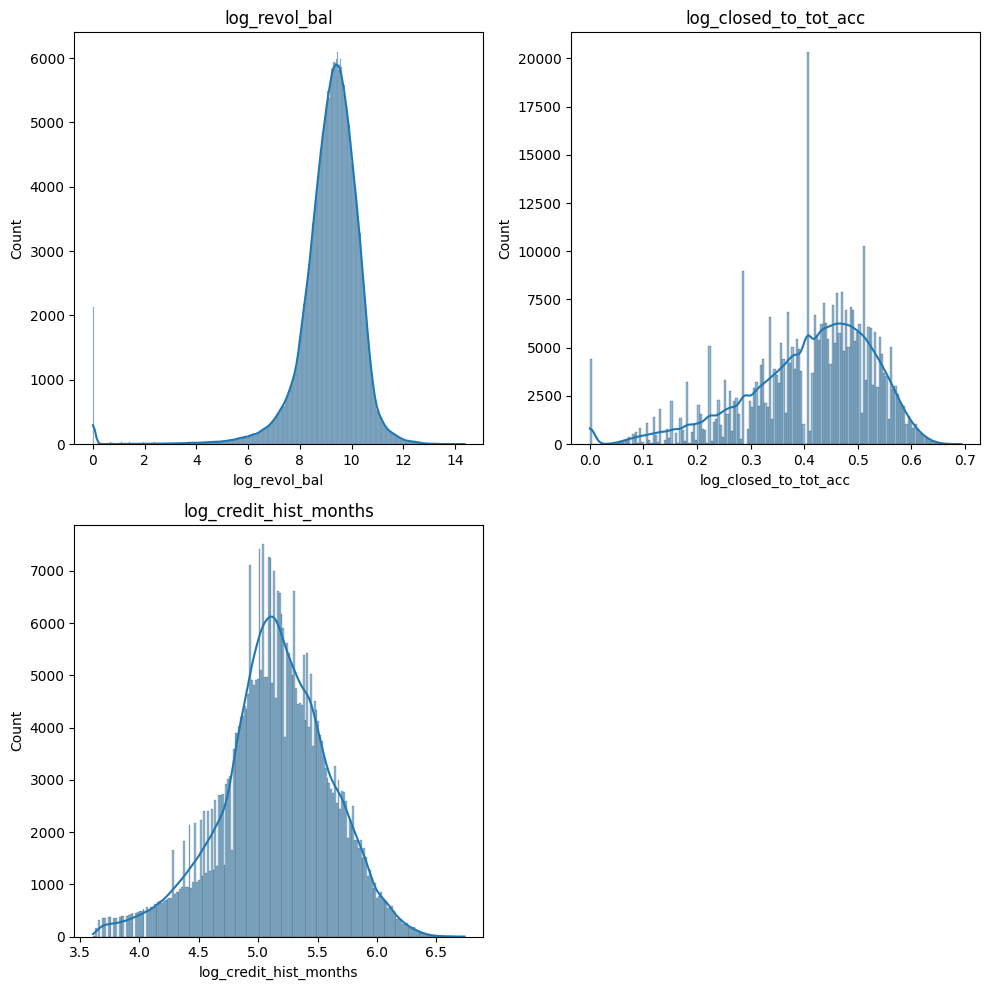

In [ ]:
plt.figure(figsize = (10, 10))
rows = 2
cols = 2
columns = ['log_revol_bal', 'log_closed_to_tot_acc', 'log_credit_hist_months']
for i in range(1, 4):
  plt.subplot(rows, cols, i)
  sns.histplot(df[columns[i-1]], kde = True)
  plt.title(columns[i-1])
plt.tight_layout()
plt.show()

# Train Test Split

In [ ]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'address', 'zip_code',
       'credit_hist_months', 'installment_to_income', 'closed_to_tot_acc',
       'log_revol_bal', 'log_closed_to_tot_acc', 'log_credit_hist_months'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'purpose', 'title',
       'dti', 'earliest_cr_line', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'application_type',
       'mort_acc', 'pub_rec_bankruptcies', 'credit_hist_months',
       'installment_to_income', 'closed_to_tot_acc', 'log_revol_bal',
       'log_closed_to_tot_acc', 'log_credit_hist_months', 'zip_code']]

y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle = True, random_state = 42)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape} | y_train: {y_train.shape} | y_test: {y_test.shape}')

X_train: (277221, 32) | X_test: (118809, 32) | y_train: (277221,) | y_test: (118809,)


In [ ]:
X_train.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,application_type,mort_acc,pub_rec_bankruptcies,credit_hist_months,installment_to_income,closed_to_tot_acc,log_revol_bal,log_closed_to_tot_acc,log_credit_hist_months,zip_code
3412,10000.0,60.0,11.99,222.40,B,B5,medical biller,5.0,MORTGAGE,31000.0,...,INDIVIDUAL,2.0,0.0,287.0,0.086090,0.594203,7.748891,0.466374,5.662960,00813
134032,12425.0,60.0,25.78,370.40,F,F5,supervisor,10.0,RENT,65500.0,...,INDIVIDUAL,0.0,1.0,269.0,0.067860,0.733333,6.548219,0.550046,5.598422,48052
19526,8000.0,36.0,9.17,255.04,B,B1,production scheduler,10.0,MORTGAGE,62000.0,...,INDIVIDUAL,6.0,0.0,222.0,0.049363,0.638298,10.470816,0.493658,5.407172,00813
61015,15000.0,36.0,7.62,467.43,A,A3,executive chef,10.0,MORTGAGE,45000.0,...,INDIVIDUAL,5.0,0.0,225.0,0.124648,0.727273,9.474779,0.546544,5.420535,48052
2896,15000.0,36.0,13.99,512.60,C,C4,casing tech.,10.0,OWN,35000.0,...,INDIVIDUAL,0.0,0.0,180.0,0.175749,0.704545,9.080459,0.533298,5.198497,29597


In [ ]:
y_train.head()

,loan_status
3412,Fully Paid
134032,Fully Paid
19526,Fully Paid
61015,Fully Paid
2896,Fully Paid


# Data Driven Feature Engineering

In [ ]:
top_50_titles = X_train['title'].value_counts().head(50).index
top_50_emp_titles = X_train['emp_title'].value_counts().head(50).index

X_train['title_processed'] = X_train['title'].apply(lambda x: x if x in top_50_titles else 'other')
X_test['title_processed'] = X_test['title'].apply(lambda x: x if x in top_50_titles else 'other')

X_train['emp_title_processed'] = X_train['emp_title'].apply(lambda x: x if x in top_50_emp_titles else 'other')
X_test['emp_title_processed'] = X_test['emp_title'].apply(lambda x: x if x in top_50_emp_titles else 'other')

X_train = X_train.drop(columns=['title', 'emp_title'])
X_test = X_test.drop(columns=['title', 'emp_title'])

In [ ]:
X_train['title_processed'].value_counts()

,count
title_processed,
debt consolidation,118361
other,67341
credit card refinancing,36222
home improvement,12123
consolidation,4132
major purchase,3565
debt consolidation loan,2501
business,2150
medical expenses,1957


In [ ]:
from sklearn.preprocessing import TargetEncoder

high_card_cols = ['title_processed', 'emp_title_processed', 'zip_code']

te = TargetEncoder(smooth = 10.0)

X_train[high_card_cols] = te.fit_transform(X_train[high_card_cols], y_train)
X_test[high_card_cols] = te.transform(X_test[high_card_cols])

In [ ]:
X_train[['title_processed', 'emp_title_processed', 'zip_code']].head()

,title_processed,emp_title_processed,zip_code
3412,0.776202,0.814140,0.999924
134032,0.776108,0.754487,0.799427
19526,0.809770,0.814140,0.999924
61015,0.852109,0.813524,0.801167
2896,0.776108,0.813573,0.999923


# Imputing Missing Values

In [ ]:
X_train.isna().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_length,12844
home_ownership,0
annual_inc,0
verification_status,0


In [ ]:
from sklearn.impute import SimpleImputer

median_num_cols = ['emp_title_processed', 'emp_length', 'title_processed', 'revol_util', 'mort_acc']

median_imputer = SimpleImputer(strategy='median')

X_train[median_num_cols] = median_imputer.fit_transform(X_train[median_num_cols])
X_test[median_num_cols] = median_imputer.transform(X_test[median_num_cols])

print("Remaining missing values in Train:", X_train.isnull().sum())
print("Remaining missing values in Test:", X_test.isnull().sum())


Remaining missing values in Train: loan_amnt                   0
term                        0
int_rate                    0
installment                 0
grade                       0
sub_grade                   0
emp_length                  0
home_ownership              0
annual_inc                  0
verification_status         0
issue_d                     0
purpose                     0
dti                         0
earliest_cr_line            0
open_acc                    0
pub_rec                     0
revol_bal                   0
revol_util                  0
total_acc                   0
initial_list_status         0
application_type            0
mort_acc                    0
pub_rec_bankruptcies      367
credit_hist_months          0
installment_to_income       0
closed_to_tot_acc           0
log_revol_bal               0
log_closed_to_tot_acc       0
log_credit_hist_months      0
zip_code                    0
title_processed             0
emp_title_processed         0
dtype

# Dropping Columns

In [ ]:
columns_to_drop = ['open_acc', 'total_acc', 'annual_inc', 'pub_rec_bankruptcies', 'earliest_cr_line', 'loan_amnt', 'installment', 'issue_d', 'revol_bal', 'closed_to_tot_acc', 'credit_hist_months', 'sub_grade', 'application_type', 'grade']

In [ ]:
X_train = X_train.drop(columns = columns_to_drop)
X_test = X_test.drop(columns = columns_to_drop)

In [ ]:
X_train.head(1).T

,3412
term,60.0
int_rate,11.99
emp_length,5.0
home_ownership,MORTGAGE
verification_status,Not Verified
purpose,debt_consolidation
dti,27.78
pub_rec,0.0
revol_util,6.9
initial_list_status,w


# Outlier Processing

In [ ]:
outlier_cols = ['installment_to_income', 'log_credit_hist_months', 'revol_util', 'log_revol_bal', 'pub_rec', 'dti']

for col in outlier_cols:

    upper_limit = X_train[col].quantile(0.99)

    X_train[col] = X_train[col].clip(upper=upper_limit)
    X_test[col] = X_test[col].clip(upper=upper_limit)

print("Winsorization complete! All extreme outliers have been securely capped.")


Winsorization complete! All extreme outliers have been securely capped.


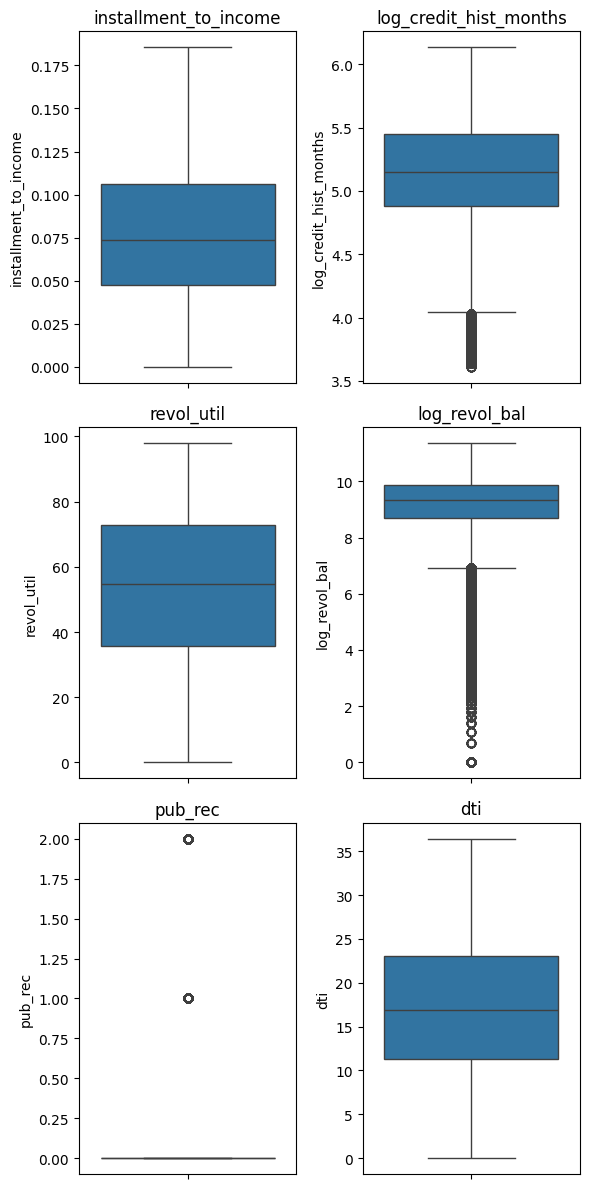

In [ ]:
plt.figure(figsize = (6, 12))
rows = (len(outlier_cols) + 1) // 2
cols = 2
for i in range(1, len(outlier_cols) + 1):
  plt.subplot(rows, cols, i)
  sns.boxplot(X_train[outlier_cols[i-1]])
  plt.title(outlier_cols[i-1])
plt.tight_layout()
plt.show()

# Encoding

## Grouping

In [ ]:
X_train['home_ownership'].value_counts().index

Index(['MORTGAGE', 'RENT', 'OWN', 'OTHER', 'NONE', 'ANY'], dtype='object', name='home_ownership')

In [ ]:
X_train['purpose'].value_counts().index

Index(['debt_consolidation', 'credit_card', 'home_improvement', 'other',
       'major_purchase', 'small_business', 'car', 'medical', 'moving',
       'vacation', 'house', 'wedding', 'renewable_energy', 'educational'],
      dtype='object', name='purpose')

In [ ]:
X_train.head()

,term,int_rate,emp_length,home_ownership,verification_status,purpose,dti,pub_rec,revol_util,initial_list_status,mort_acc,installment_to_income,log_revol_bal,log_closed_to_tot_acc,log_credit_hist_months,zip_code,title_processed,emp_title_processed
3412,60.0,11.99,5.0,MORTGAGE,Not Verified,debt_consolidation,27.78,0.0,6.9,w,2.0,0.086090,7.748891,0.466374,5.662960,0.999924,0.776202,0.814140
134032,60.0,25.78,10.0,RENT,Verified,debt_consolidation,7.86,1.0,11.6,w,0.0,0.067860,6.548219,0.550046,5.598422,0.799427,0.776108,0.754487
19526,36.0,9.17,10.0,MORTGAGE,Not Verified,credit_card,22.67,0.0,77.2,f,6.0,0.049363,10.470816,0.493658,5.407172,0.999924,0.809770,0.814140
61015,36.0,7.62,10.0,MORTGAGE,Source Verified,debt_consolidation,19.78,0.0,22.1,w,5.0,0.124648,9.474779,0.546544,5.420535,0.801167,0.852109,0.813524
2896,36.0,13.99,10.0,OWN,Source Verified,debt_consolidation,36.43,0.0,49.3,w,0.0,0.175749,9.080459,0.533298,5.198497,0.999923,0.776108,0.813573


In [ ]:
X_train['home_ownership'] = X_train['home_ownership'].replace(['NONE', 'ANY'], 'OTHER')
X_test['home_ownership'] = X_test['home_ownership'].replace(['NONE', 'ANY'], 'OTHER')

In [ ]:
X_train['purpose'] = X_train['purpose'].replace(['major_purchase', 'small_business', 'car', 'medical', 'moving',
       'vacation', 'house', 'wedding', 'renewable_energy', 'educational'], 'other')
X_test['purpose'] = X_test['purpose'].replace(['major_purchase', 'small_business', 'car', 'medical', 'moving',
       'vacation', 'house', 'wedding', 'renewable_energy', 'educational'], 'other')

In [ ]:
X_test['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,59821
RENT,47803
OWN,11139
OTHER,46


In [ ]:
X_test['purpose'].value_counts()

,count
purpose,
debt_consolidation,70275
credit_card,25031
other,16346
home_improvement,7157


## Ordinal Encoding

In [ ]:
# from sklearn.preprocessing import OrdinalEncoder

# grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# sub_grade_order = ['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1', 'C2',
#        'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2', 'E3', 'E4',
#        'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3', 'G4', 'G5']

# grade_encoder = OrdinalEncoder(
#     categories=[grade_order],
#     handle_unknown='use_encoded_value',
#     unknown_value=-1,
#     encoded_missing_value=-1
# )

# X_train['grade_encoded'] = grade_encoder.fit_transform(X_train[['grade']])
# X_test['grade_encoded'] = grade_encoder.transform(X_test[['grade']])

# X_train = X_train.drop(columns=['grade'])
# X_test = X_test.drop(columns=['grade'])

## One Hot Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

nominal_cols = ['initial_list_status', 'purpose', 'verification_status',
'home_ownership']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

ohe.fit(X_train[nominal_cols])

encoded_col_names = ohe.get_feature_names_out(nominal_cols)

X_train_encoded_arr = ohe.transform(X_train[nominal_cols])
X_test_encoded_arr = ohe.transform(X_test[nominal_cols])

X_train_encoded_df = pd.DataFrame(X_train_encoded_arr, columns=encoded_col_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded_arr, columns=encoded_col_names, index=X_test.index)

X_train = X_train.drop(columns=nominal_cols)
X_test = X_test.drop(columns=nominal_cols)

X_train = pd.concat([X_train, X_train_encoded_df], axis=1)
X_test = pd.concat([X_test, X_test_encoded_df], axis=1)


In [ ]:
X_train.head(1).T

,3412
term,60.000000
int_rate,11.990000
emp_length,5.000000
dti,27.780000
pub_rec,0.000000
revol_util,6.900000
mort_acc,2.000000
installment_to_income,0.086090
log_revol_bal,7.748891
log_closed_to_tot_acc,0.466374


## Encoding target column

In [ ]:
y_train.unique()

array(['Fully Paid', 'Charged Off'], dtype=object)

In [ ]:
y_train = y_train.map({'Charged Off': 1, 'Fully Paid': 0})
y_test = y_test.map({'Charged Off': 1, 'Fully Paid': 0})

y_train.unique()

array([0, 1])

# Scaling

In [ ]:
X_train.columns

Index(['term', 'int_rate', 'emp_length', 'dti', 'pub_rec', 'revol_util',
       'mort_acc', 'installment_to_income', 'log_revol_bal',
       'log_closed_to_tot_acc', 'log_credit_hist_months', 'zip_code',
       'title_processed', 'emp_title_processed', 'initial_list_status_w',
       'purpose_debt_consolidation', 'purpose_home_improvement',
       'purpose_other', 'verification_status_Source Verified',
       'verification_status_Verified', 'home_ownership_OTHER',
       'home_ownership_OWN', 'home_ownership_RENT'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['term', 'int_rate', 'emp_length', 'dti', 'pub_rec',
       'revol_util', 'mort_acc', 'installment_to_income', 'log_revol_bal', 'log_closed_to_tot_acc',
       'log_credit_hist_months', 'title_processed', 'emp_title_processed']

scaler = StandardScaler()

scaler.fit(X_train[scale_cols])

X_train[scale_cols] = scaler.transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])


In [ ]:
X_train.head(1).T

,3412
term,1.795370
int_rate,-0.366128
emp_length,-0.264368
dti,1.294790
pub_rec,-0.392425
revol_util,-1.920061
mort_acc,0.129239
installment_to_income,0.174329
log_revol_bal,-1.175036
log_closed_to_tot_acc,0.472706


# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight = 'balanced', penalty='l2', C=0.001, max_iter = 1000, random_state = 42)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

In [ ]:
y_pred[:5]

array([0, 0, 0, 1, 0])

In [ ]:
y_pred_proba[:5]

array([0.48622007, 0.3005708 , 0.4927192 , 0.95065126, 0.12197227])

In [ ]:
feature_names = X_train.columns
coefficients = log_reg.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient (Weight)': coefficients
})

print(importance_df.to_string(index=False))

                            Feature  Coefficient (Weight)
                               term              0.218572
                           int_rate              0.375831
                         emp_length             -0.025198
                                dti              0.194146
                            pub_rec              0.032716
                         revol_util              0.117830
                           mort_acc             -0.059128
              installment_to_income              0.152004
                      log_revol_bal             -0.092014
              log_closed_to_tot_acc             -0.088969
             log_credit_hist_months              0.011638
                           zip_code             -4.329821
                    title_processed             -0.126303
                emp_title_processed             -0.137568
              initial_list_status_w             -0.019136
         purpose_debt_consolidation             -0.021307
           pur

In [ ]:
importance_df['Mod_Coefficient'] = abs(importance_df['Coefficient (Weight)'])

In [ ]:
importance_df.sort_values(by = 'Mod_Coefficient', ascending = False)

,Feature,Coefficient (Weight),Mod_Coefficient
11,zip_code,-4.329821,4.329821
1,int_rate,0.375831,0.375831
0,term,0.218572,0.218572
22,home_ownership_RENT,0.198713,0.198713
3,dti,0.194146,0.194146
7,installment_to_income,0.152004,0.152004
13,emp_title_processed,-0.137568,0.137568
12,title_processed,-0.126303,0.126303
5,revol_util,0.117830,0.117830
18,verification_status_Source Verified,0.107990,0.107990


As it can be seen that zip code, int_rate and term have highest coefficients which indicate these have the highest influence on target.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print("--- Variance Inflation Factor (VIF) Report ---")
print(vif_data)

--- Variance Inflation Factor (VIF) Report ---
                                Feature       VIF
0                              zip_code  5.547612
1            purpose_debt_consolidation  3.520819
2                   home_ownership_RENT  2.262767
3          verification_status_Verified  2.168054
4   verification_status_Source Verified  1.984732
5                 initial_list_status_w  1.747731
6                              int_rate  1.718216
7                         purpose_other  1.678888
8                         log_revol_bal  1.570279
9                            revol_util  1.529976
10                             mort_acc  1.470251
11               log_credit_hist_months  1.393448
12                                 term  1.391111
13                log_closed_to_tot_acc  1.297152
14             purpose_home_improvement  1.277486
15                      title_processed  1.245661
16                   home_ownership_OWN  1.226925
17                installment_to_income  1.222277
18 

Mostly all of the features have VIF <=5, so there is negligible multicollinearity.

# Evaluation

--- Classification Performance Report ---
              precision    recall  f1-score   support

  Fully Paid       0.92      0.87      0.90     95439
 Charged Off       0.57      0.70      0.63     23370

    accuracy                           0.84    118809
   macro avg       0.75      0.79      0.76    118809
weighted avg       0.85      0.84      0.84    118809

ROC-AUC Score: 0.8853



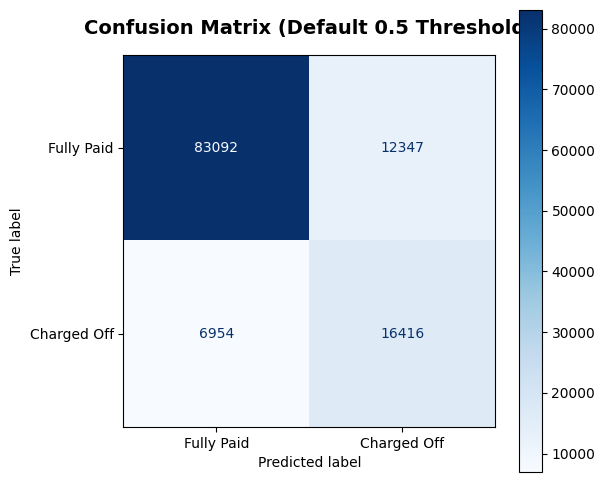

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

print("--- Classification Performance Report ---")
print(classification_report(y_test, y_pred, target_names=["Fully Paid", "Charged Off"]))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fully Paid", "Charged Off"])

# Plot formatting
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Default 0.5 Threshold)", fontsize=14, fontweight="bold", pad=15)
plt.grid(False)
plt.show()

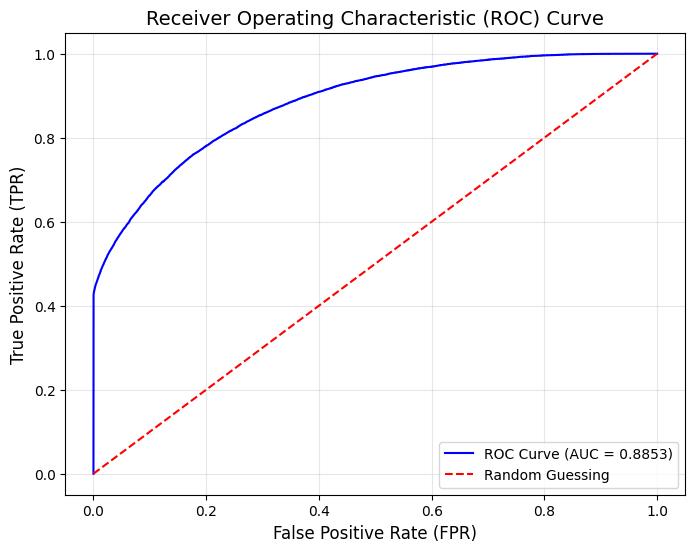

In [ ]:
from sklearn.metrics import roc_curve

auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')

plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


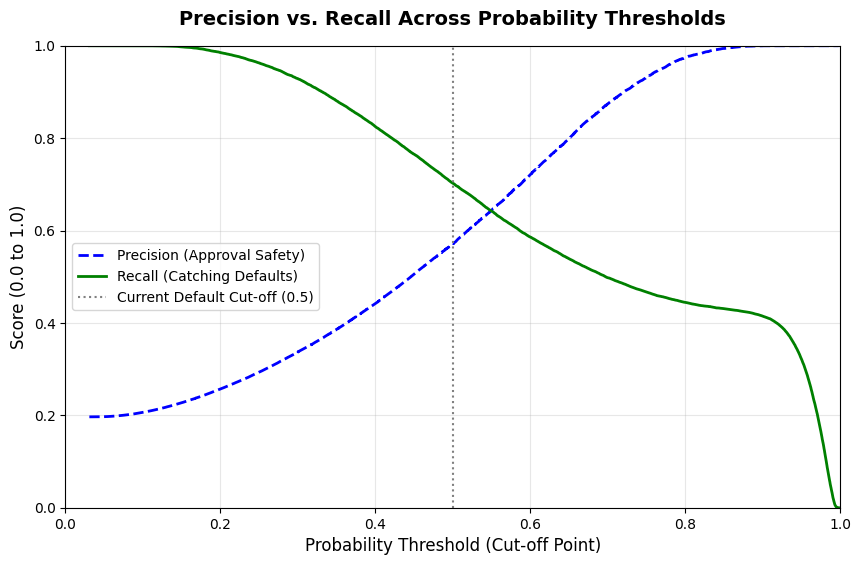

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Approval Safety)', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Catching Defaults)', linewidth=2)

plt.title('Precision vs. Recall Across Probability Thresholds', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Probability Threshold (Cut-off Point)', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.axvline(x=0.5, color='gray', linestyle=':', label='Current Default Cut-off (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.legend(loc='center left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()


### Insights from Evaluation

Based on the logistic regression model's performance on the test set:

*   **Overall Performance (ROC-AUC)**: The model achieved a strong ROC-AUC score of **0.8854**. This indicates excellent discriminatory power, meaning the model is very good at distinguishing between 'Fully Paid' and 'Charged Off' loans.

*   **Precision and Recall for 'Charged Off' Loans**: For the minority class ('Charged Off'), the model shows:
    *   **Precision: 0.57**: When the model predicts a loan will be 'Charged Off', it is correct 57% of the time. This means there are a notable number of false positives (creditworthy applicants incorrectly flagged).
    *   **Recall: 0.70**: The model successfully identifies 70% of all actual 'Charged Off' loans. This is a good recall, indicating the model catches a significant portion of risky loans.
    *   **F1-Score: 0.63**: This balanced score reflects a reasonable trade-off between precision and recall for the 'Charged Off' class.

*   **Overall Accuracy**: The model achieved an overall accuracy of **0.84**. While high, accuracy can be misleading in imbalanced datasets, so ROC-AUC and class-specific metrics are more informative.

*   **Most Influential Features (Logistic Regression Coefficients)**:
    The features with the highest absolute coefficients, indicating their strong influence on the prediction of 'Charged Off' status, are:
    1.  `zip_code`: By far the most influential feature, suggesting strong geographical patterns in loan default.
    2.  `int_rate`: Higher interest rates are strongly associated with higher default probability.
    3.  `term`: Longer loan terms (60 months) increase the likelihood of default.
    4.  `home_ownership_RENT`: Renters show a higher propensity for default compared to other homeownership statuses.
    5.  `dti` (Debt-to-Income): Higher DTI is linked to increased default risk.
    6.  `installment_to_income`: A larger proportion of income going towards installments is a significant risk factor.
    7.  `emp_title_processed` and `title_processed`: These processed employment and loan purpose titles also carry substantial weight, with negative coefficients suggesting that certain categories within these features are associated with lower default risk (after target encoding).

In summary, the model demonstrates robust performance in identifying loan defaults, especially given the imbalanced nature of the target variable. The identified key features provide valuable insights for refining lending strategies.

Tradeoff Questions:

1. How can we make sure that our model can detect real defaulters and there are less false positives?

Ans ->

To ensure the model catches real defaulters while minimizing False Positives (creditworthy applicants who are mistakenly rejected), the bank must focus on maximizing Precision without severely crashing Recall. This preserves the opportunity to finance good applicants and earn interest.

2. Since NPA (non-performing asset) is a real problem in this industry, it’s important we play safe and shouldn’t disburse loans to anyone.

Ans->

When managing a high Non-Performing Asset (NPA) environment, the bank's core mandate shifts from revenue expansion to capital preservation. The primary objective becomes maximizing Recall.

# Actionable Insights and Recommendations

### Actionable Insights

Based on the logistic regression model and exploratory data analysis, here are some actionable insights and recommendations for the bank:

1.  **Interest Rate and Term are Key Risk Indicators**: The model highlights `int_rate` and `term` as significant predictors of loan default. Higher interest rates and longer loan terms (60 months) are associated with a higher likelihood of default.
    *   **Recommendation**: Review lending policies for higher-interest, longer-term loans. Consider stricter eligibility criteria or higher collateral requirements for these segments. Develop more granular interest rate tiers based on risk profiles.

2.  **Home Ownership Matters**: `home_ownership_RENT` and `home_ownership_OWN` are strong indicators. Renters might have a higher risk profile compared to homeowners.
    *   **Recommendation**: Further investigate the financial stability of renters versus owners. Tailor loan products or risk assessment for different home ownership statuses.

3.  **Debt Consolidation is a Common Purpose, but with Nuance**: While `debt_consolidation` is the most common loan purpose, its impact on default probability can vary. The model's coefficients indicate that purpose-related features influence outcomes.
    *   **Recommendation**: For 'debt_consolidation' loans, implement more rigorous checks on the borrower's overall debt burden and repayment capacity. Consider financial literacy programs for these borrowers.

4.  **Employment Stability and History**: `emp_length` (employment length) is a factor, suggesting that borrowers with longer employment histories are generally more reliable. `emp_title_processed` also carries weight, indicating that certain job roles might be more stable.
    *   **Recommendation**: Place a stronger emphasis on consistent employment history during the application review process. Analyze the performance of loans granted to different `emp_title` categories to refine risk assessment.

5.  **DTI and Installment-to-Income Ratio**: `dti` and `installment_to_income` are important. Higher debt-to-income ratios and a larger proportion of income going to loan installments indicate increased risk.
    *   **Recommendation**: Reinforce strict DTI limits and carefully evaluate the `installment_to_income` ratio. Consider offering financial counseling to applicants with borderline ratios to help them manage their finances better.

6.  **Geographical Impact (Zip Code)**: The `zip_code` feature emerged as highly influential, suggesting that geographical location plays a significant role in loan default rates. This could be due to local economic conditions, employment rates, or cost of living.
    *   **Recommendation**: Conduct a deeper analysis into the specific `zip_code` areas identified as high-risk. This could involve geographical risk mapping and adjusting lending strategies for specific regions.

7.  **ROC-AUC and Imbalanced Classes**: The model achieved a good ROC-AUC score of 0.8854, indicating strong discriminatory power. However, the class imbalance (more 'Fully Paid' than 'Charged Off') was addressed using `class_weight='balanced'` to prevent bias.
    *   **Recommendation**: Continuously monitor the performance metrics, especially recall, to ensure that the model is effectively identifying potential defaulters. Regularly re-evaluate the balancing strategy as data distributions evolve.

# Questionnaire

1. What percentage of customers have fully paid their Loan Amount?

Ans-> 80.38 percent of customers have fully paid their Loan Amount.

2. Comment about the correlation between Loan Amount and Installment features.

Ans-> Loan amount and Installment have very high correlation of 0.95. It is is better to remove one of the feature or do feature engineering for a better model.

3. The majority of people have home ownership as _______.

Ans-> MORTAGE

4. People with grades ‘A’ are more likely to fully pay their loan. (T/F)

Ans-> T

5. Name the top 2 afforded job titles.

Ans-> Manager and Teacher

6. Thinking from a bank's perspective, which metric should our primary focus be on..
a. ROC AUC
b. Precision
c. Recall
d. F1 Score

Ans->

c(Recall)

High recall ensures that the bank catches and flags as many defaulters as possible.

7. How does the gap in precision and recall affect the bank?

Ans->

High Recall / Low Precision: The bank catches almost all defaulters, but flags too many creditworthy applicants as risky. This leads to high rejection rates, lost revenue from missed interest, and poor customer experience.

High Precision / Low Recall: The bank accepts most good applicants, but misses actual defaulters. This results in heavy financial losses due to bad debt and non-performing assets (NPAs).

8. Which were the features that heavily affected the outcome?

Ans-> interest_rate, term

9. Will the results be affected by geographical location? (Yes/No)

Ans-> Yes


In [ ]:
# ⚙️ Convert notebook to high-quality PDF
NOTEBOOK_NAME="Business_Case_LoanTap_Logistic_Regression.ipynb"          # 👈 change this if your file has another name
HTML_NAME="Business_Case_LoanTap_Logistic_Regression.ipynb.html"
PDF_NAME="Business_Case_LoanTap_Logistic_Regression.ipynb.pdf"

# Convert notebook → HTML
!jupyter nbconvert --to html "/content/$NOTEBOOK_NAME" --output "/content/$HTML_NAME"

[NbConvertApp] Converting notebook /content/Business_Case_LoanTap_Logistic_Regression.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 2600671 bytes to /content/Business_Case_LoanTap_Logistic_Regression.ipynb.html


In [ ]:
import os

# Install wkhtmltopdf
!sudo apt-get update
!sudo apt-get install wkhtmltopdf -y

# Convert HTML → high-quality PDF
!wkhtmltopdf --zoom 2 --dpi 300 "/content/$HTML_NAME" "/content/$PDF_NAME"

# 📥 Download the resulting PDF
from google.colab import files
files.download("/content/" + PDF_NAME)

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:4 https://cli.github.com/packages stable InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,301 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,183 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,006 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,608 kB]
Get

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>